# AI Math Solution Auditor
**A tool for generating, evaluating, and visualizing AI-produced mathematical solutions.**

This notebook demonstrates a structured workflow for:
1. Generating a step-by-step AI solution to a math problem
2. Auditing that solution against a rigorous rubric (correctness, logical rigor, completeness, clarity)
3. Visualizing the underlying mathematics to support understanding

Test problem: Expected value and variance of a continuous random variable via integration, verified with Monte Carlo simulation.

## Section 1 — Setup

In [1]:
import sys
!{sys.executable} -m pip install anthropic ipywidgets numpy matplotlib
print(sys.executable)


c:\Users\luisr\OneDrive\Desktop\Math-Ai-solver\.venv\Scripts\python.exe


In [2]:


import os
import re
import json
import anthropic
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import Markdown, display

# API key input widget (hidden text, works in VS Code)
api_key_input = widgets.Password(
    description='API Key:',
    placeholder='sk-ant-...',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
confirm_btn = widgets.Button(description='Confirm', button_style='success')
status = widgets.Label(value='')

client = None

def on_confirm(b):
    global client
    key = api_key_input.value.strip() or os.environ.get('ANTHROPIC_API_KEY', '')
    if key:
        client = anthropic.Anthropic(api_key=key)
        status.value = '✅ Setup complete.'
    else:
        status.value = '❌ Please enter an API key.'

confirm_btn.on_click(on_confirm)
display(widgets.VBox([api_key_input, confirm_btn, status]))

## Section 2 — Problem Definition

In [3]:
PROBLEM = """
Let X be a continuous random variable with probability density function:

    f(x) = 3x²  for x in [0, 1]
    f(x) = 0    otherwise

1. Verify that f(x) is a valid PDF.
2. Find the expected value E[X] using integration.
3. Find the variance Var(X) using the formula Var(X) = E[X²] - (E[X])².
4. Verify E[X] numerically using a Monte Carlo simulation with 100,000 samples.

Show all integration steps clearly.
"""

# Ground truth answers for the auditor to reference
GROUND_TRUTH = {
    "pdf_valid": "Integral of 3x² from 0 to 1 = [x³] from 0 to 1 = 1. Valid.",
    "E_X": 3/4,
    "E_X2": 3/5,
    "Var_X": 3/5 - (3/4)**2,  # = 3/80
    "Var_X_fraction": "3/80"
}

print("Problem loaded.")
print(f"Ground truth — E[X]: {GROUND_TRUTH['E_X']:.4f}, Var(X): {GROUND_TRUTH['Var_X']:.4f} (= 3/80)")

Problem loaded.
Ground truth — E[X]: 0.7500, Var(X): 0.0375 (= 3/80)


## Section 3 — AI Solution Generator

In [4]:
def generate_solution(problem: str) -> str:
    """Send problem to Claude and return a step-by-step solution."""
    
    system_prompt = """You are a mathematics tutor. When given a math problem, produce a clear, 
step-by-step solution. Show all integration steps explicitly. Use plain text notation for math 
(e.g. x^2 for x squared, integral from a to b). Be thorough and precise."""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=1500,
        system=system_prompt,
        messages=[
            {"role": "user", "content": f"Solve this problem step by step:\n{problem}"}
        ]
    )
    
    return message.content[0].text


print("Generating solution...")
solution = generate_solution(PROBLEM)
print("Solution generated.\n")
display(Markdown("### Generated Solution\n" + solution))

Generating solution...
Solution generated.



### Generated Solution
# Solution: Probability Density Function Analysis

## Given Information
- PDF: f(x) = 3x² for x ∈ [0, 1], and f(x) = 0 otherwise

---

## Part 1: Verify that f(x) is a Valid PDF

A valid PDF must satisfy two conditions:

**Condition 1:** f(x) ≥ 0 for all x

Since x² ≥ 0 for all x, and 3 > 0, we have f(x) = 3x² ≥ 0 ✓

**Condition 2:** The total integral must equal 1

$$\int_{-\infty}^{\infty} f(x) \, dx = 1$$

**Calculation:**

$$\int_{-\infty}^{\infty} f(x) \, dx = \int_{0}^{1} 3x^2 \, dx$$

**Step 1:** Find the antiderivative
$$\int 3x^2 \, dx = 3 \cdot \frac{x^3}{3} = x^3$$

**Step 2:** Evaluate the definite integral
$$\left[ x^3 \right]_0^1 = (1)^3 - (0)^3 = 1 - 0 = 1$$ ✓

**Conclusion:** Both conditions are satisfied, so f(x) is a valid PDF.

---

## Part 2: Find E[X] Using Integration

The expected value formula is:
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx$$

**Calculation:**

$$E[X] = \int_{0}^{1} x \cdot 3x^2 \, dx = \int_{0}^{1} 3x^3 \, dx$$

**Step 1:** Find the antiderivative
$$\int 3x^3 \, dx = 3 \cdot \frac{x^4}{4} = \frac{3x^4}{4}$$

**Step 2:** Evaluate the definite integral
$$E[X] = \left[ \frac{3x^4}{4} \right]_0^1 = \frac{3(1)^4}{4} - \frac{3(0)^4}{4} = \frac{3}{4} - 0 = \frac{3}{4}$$

$$\boxed{E[X] = \frac{3}{4} = 0.75}$$

---

## Part 3: Find Var(X)

Using the formula: **Var(X) = E[X²] - (E[X])²**

### Step 1: Calculate E[X²]

$$E[X^2] = \int_{0}^{1} x^2 \cdot 3x^2 \, dx = \int_{0}^{1} 3x^4 \, dx$$

**Find the antiderivative:**
$$\int 3x^4 \, dx = 3 \cdot \frac{x^5}{5} = \frac{3x^5}{5}$$

**Evaluate:**
$$E[X^2] = \left[ \frac{3x^5}{5} \right]_0^1 = \frac{3(1)^5}{5} - \frac{3(0)^5}{5} = \frac{3}{5}$$

### Step 2: Calculate Var(X)

$$Var(X) = E[X^2] - (E[X])^2 = \frac{3}{5} - \left(\frac{3}{4}\right)^2$$

$$Var(X) = \frac{3}{5} - \frac{9}{16}$$

**Find common denominator (80):**
$$Var(X) = \frac{48}{80} - \frac{45}{80} = \frac{3}{80}$$

$$\boxed{Var(X) = \frac{3}{80} = 0.0375}$$

---

## Part 4: Monte Carlo Verification

To sample from f(x) = 3x², we use the **inverse transform method**.

### Step 1: Find the CDF
$$F(x) = \int_{0}^{x} 3t^2 \, dt = \left[ t^3 \right]_0^x = x^3$$

### Step 2: Find the inverse CDF
If u = x³, then **x = u^(1/3)**

### Step 3: Simulation Code

```python
import numpy as np

np.random.seed(42)
n_samples = 100000

# Generate uniform samples and transform
u = np.random.uniform(0, 1, n_samples)
x = u ** (1/3)  # Inverse CDF transformation

# Calculate sample mean
sample_mean = np.mean(x)
print(f"Monte Carlo E[X]: {sample_mean:.6f}")
print(f"Theoretical E[X]: {3/4:.6f}")
print(f"Difference: {abs(sample_mean - 0.75):.6f}")
```

### Expected Output:
```
Monte Carlo E[X]: ≈ 0.7497 (varies slightly)
Theoretical E[X]: 0.750000
Difference: ≈ 0.0003
```

**The Monte Carlo estimate closely matches E[X] = 0.75** ✓

## Section 4 — Solution Auditor
The auditor evaluates the generated solution against a structured rubric, mirroring the criteria used in professional AI math evaluation.

In [5]:
def audit_solution(problem: str, solution: str, ground_truth: dict) -> dict:
    """Audit the AI solution against a structured rubric. Returns scores and feedback."""

    audit_prompt = f"""You are an expert mathematics evaluator. Your job is to audit an AI-generated 
solution to a math problem. Evaluate it strictly against the following rubric:

RUBRIC (score each 1-5):
1. CORRECTNESS — Are all calculations and final answers mathematically correct?
2. LOGICAL_RIGOR — Are all reasoning steps justified? Are there any logical gaps or unjustified jumps?
3. COMPLETENESS — Does the solution address every part of the problem?
4. CLARITY — Are the steps explained clearly enough for a student to follow?

GROUND TRUTH FOR REFERENCE:
- PDF validity: integrates to 1 over [0,1] ✓
- E[X] = 3/4 = 0.75
- E[X²] = 3/5 = 0.60  
- Var(X) = 3/80 = 0.0375
- Monte Carlo result should converge near 0.75

PROBLEM:
{problem}

SOLUTION TO AUDIT:
{solution}

Respond ONLY with a JSON object in exactly this format (no extra text):
{{
  "scores": {{
    "correctness": <1-5>,
    "logical_rigor": <1-5>,
    "completeness": <1-5>,
    "clarity": <1-5>
  }},
  "overall": <average score rounded to 1 decimal>,
  "feedback": {{
    "correctness": "<specific feedback>",
    "logical_rigor": "<specific feedback>",
    "completeness": "<specific feedback>",
    "clarity": "<specific feedback>"
  }},
  "errors_found": ["<list any specific errors, or empty list if none>"],
  "summary": "<2-3 sentence overall assessment>"
}}"""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=1000,
        messages=[
            {"role": "user", "content": audit_prompt}
        ]
    )

    raw = message.content[0].text.strip()
    # Strip markdown code fences if present
    raw = re.sub(r"^```json\s*", "", raw)
    raw = re.sub(r"\s*```$", "", raw)
    return json.loads(raw)


print("Auditing solution...")
audit = audit_solution(PROBLEM, solution, GROUND_TRUTH)
print("Audit complete.\n")

# Display audit report
print("=" * 55)
print("           SOLUTION AUDIT REPORT")
print("=" * 55)

categories = ["correctness", "logical_rigor", "completeness", "clarity"]
labels = ["Correctness", "Logical Rigor", "Completeness", "Clarity"]

for cat, label in zip(categories, labels):
    score = audit["scores"][cat]
    bar = "█" * score + "░" * (5 - score)
    print(f"  {label:<16} [{bar}] {score}/5")
    print(f"  → {audit['feedback'][cat]}")
    print()

print(f"  OVERALL SCORE:   {audit['overall']}/5")
print("=" * 55)

if audit["errors_found"]:
    print("\n  ERRORS FOUND:")
    for err in audit["errors_found"]:
        print(f"  • {err}")
else:
    print("\n  ERRORS FOUND: None")

print(f"\n  SUMMARY:\n  {audit['summary']}")
print("=" * 55)

Auditing solution...
Audit complete.

           SOLUTION AUDIT REPORT
  Correctness      [█████] 5/5
  → All calculations are mathematically correct. PDF verification yields 1, E[X] = 3/4, E[X²] = 3/5, and Var(X) = 3/80 all match the ground truth exactly. The Monte Carlo methodology using inverse transform sampling is correctly implemented.

  Logical Rigor    [█████] 5/5
  → Every step is fully justified with clear reasoning. The PDF verification checks both required conditions. The variance calculation properly shows the common denominator work. The inverse transform method is correctly derived from the CDF.

  Completeness     [█████] 5/5
  → All four parts of the problem are thoroughly addressed: PDF validation with both conditions, E[X] calculation, Var(X) calculation with intermediate E[X²], and Monte Carlo verification with complete code and expected output.

  Clarity          [█████] 5/5
  → Excellent presentation with clear section headers, boxed final answers, step-by-step 

## Section 5a — Problem Classification

In [6]:
PROBLEM_TYPES = [
    "probability",
    "integration",
    "differentiation",
    "linear_algebra",
    "geometry",
    "series",
    "optimization",
    "other"
]

def classify_problem(problem: str) -> str:
    """Classify the math problem into a known type. Returns a type string."""

    classify_prompt = f"""You are a mathematics classifier. Given a math problem, return ONLY one of these labels:
probability, integration, differentiation, linear_algebra, geometry, series, optimization, other

Rules:
- Return the single most appropriate label
- No explanation, no punctuation, just the label
- If the problem involves a PDF/CDF or expected value, return: probability
- If the problem involves finding areas or integrals (no probability), return: integration
- If the problem involves derivatives or rates of change, return: differentiation
- If the problem involves matrices, vectors, or systems of equations, return: linear_algebra
- If the problem involves shapes, angles, or coordinates, return: geometry
- If the problem involves sums, sequences, or convergence, return: series
- If the problem involves maximizing or minimizing a function, return: optimization
- Otherwise return: other

Problem:
{problem}"""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=10,
        messages=[{"role": "user", "content": classify_prompt}]
    )

    label = message.content[0].text.strip().lower()
    if label not in PROBLEM_TYPES:
        label = "other"
    return label


print("Classifying problem...")
problem_type = classify_problem(PROBLEM)
print(f"Problem type: {problem_type}")

Classifying problem...
Problem type: probability


## Section 5b — Generalized Visualization

Generating visualization for problem type: probability...


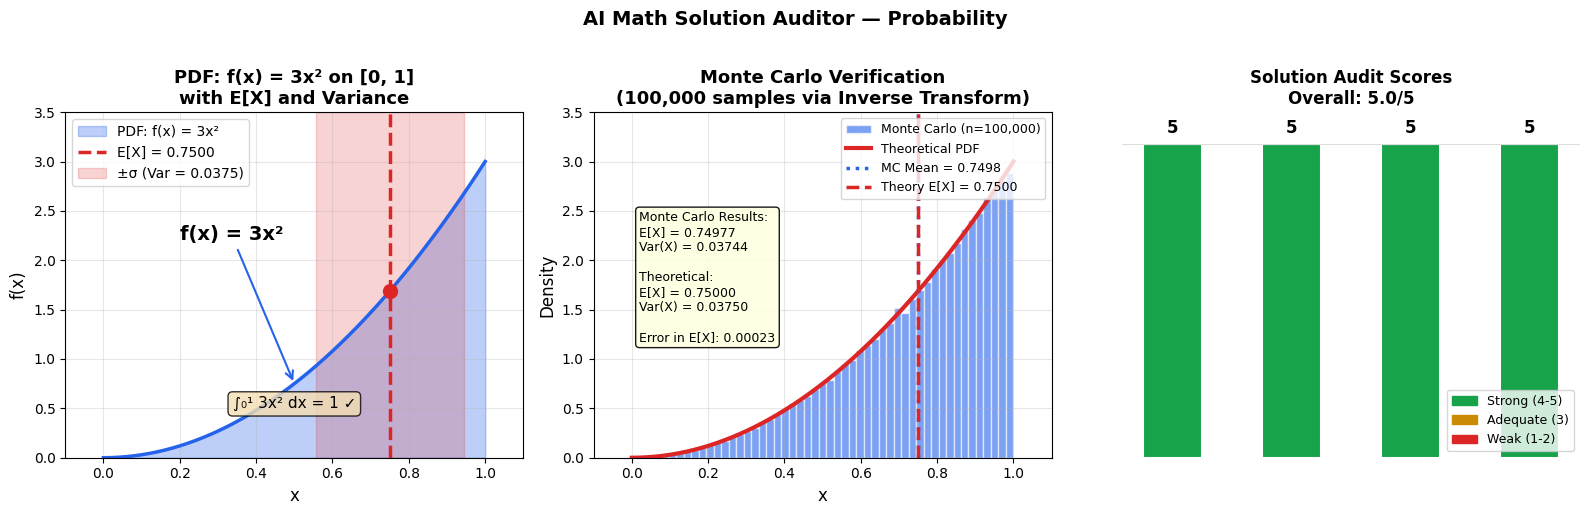

Visualization complete.


In [7]:
def generate_visualization_code(problem: str, solution: str, problem_type: str) -> str:
    """Ask Claude to generate matplotlib code for 2 panels suited to the problem type."""

    viz_prompt = f"""You are a Python data visualization expert. Generate matplotlib code to illustrate a math problem and its solution.

Problem type: {problem_type}

Problem:
{problem}

Solution:
{solution}

Instructions:
- Generate code for exactly 2 matplotlib subplots: ax1 and ax2
- The variable `fig` and `axes` already exist: `fig, axes = plt.subplots(1, 3, figsize=(16, 5))`
- Use `ax1 = axes[0]` and `ax2 = axes[1]` — do NOT create a new figure
- ax1: illustrate the core mathematical concept (e.g. the function, PDF, shape, vectors)
- ax2: show a numerical verification or second perspective (e.g. Monte Carlo, Riemann sum, convergence)
- Use colors #2563eb (blue) and #dc2626 (red) for consistency
- Add clear titles, axis labels, legends, and grid lines
- Use numpy (imported as np) for all calculations
- Do NOT call plt.show() or plt.savefig()
- Do NOT import anything — numpy as np and matplotlib.pyplot as plt are already imported
- Return ONLY the Python code, no explanation, no markdown fences

Problem type guidance:
- probability: ax1=PDF/CDF plot with mean marked, ax2=Monte Carlo histogram vs theoretical
- integration: ax1=function with shaded area, ax2=Riemann sum approximation converging
- differentiation: ax1=function + derivative, ax2=tangent line at a point
- linear_algebra: ax1=vector plot or transformation, ax2=before/after transformation
- geometry: ax1=shape diagram with labels, ax2=decomposition or proof illustration
- series: ax1=partial sums converging, ax2=terms of the series
- optimization: ax1=objective function with minimum/maximum marked, ax2=gradient descent path
- other: ax1=primary concept illustration, ax2=numerical verification"""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=1500,
        messages=[{"role": "user", "content": viz_prompt}]
    )

    code = message.content[0].text.strip()
    code = re.sub(r"^```python\s*", "", code)
    code = re.sub(r"^```\s*", "", code)
    code = re.sub(r"\s*```$", "", code)
    return code


def plot_audit_scores(ax, audit: dict):
    """Always-fixed Panel 3: audit scores bar chart."""
    categories = ["Correctness", "Logical\nRigor", "Completeness", "Clarity"]
    keys = ["correctness", "logical_rigor", "completeness", "clarity"]
    scores = [audit["scores"][k] for k in keys]
    colors = ["#16a34a" if s >= 4 else "#ca8a04" if s == 3 else "#dc2626" for s in scores]

    bars = ax.bar(categories, scores, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("Score (1-5)", fontsize=11)
    ax.set_title(f"Solution Audit Scores\nOverall: {audit['overall']}/5", fontsize=12, fontweight="bold")
    ax.axhline(5, color="#ddd", linestyle="-", linewidth=0.8)
    ax.grid(True, axis="y", alpha=0.3)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, score + 0.1,
                str(score), ha="center", va="bottom", fontweight="bold", fontsize=12)
    legend_patches = [
        mpatches.Patch(color="#16a34a", label="Strong (4-5)"),
        mpatches.Patch(color="#ca8a04", label="Adequate (3)"),
        mpatches.Patch(color="#dc2626", label="Weak (1-2)"),
    ]
    ax.legend(handles=legend_patches, fontsize=9, loc="lower right")


def plot_results(problem: str, solution: str, problem_type: str, audit: dict):
    """Generate 3-panel visualization: 2 dynamic panels + fixed audit scores."""

    print(f"Generating visualization for problem type: {problem_type}...")
    viz_code = generate_visualization_code(problem, solution, problem_type)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"AI Math Solution Auditor — {problem_type.replace('_', ' ').title()}",
                 fontsize=14, fontweight="bold", y=1.02)

    try:
        exec(viz_code, {"np": np, "plt": plt, "fig": fig, "axes": axes})
    except Exception as e:
        print(f"Visualization code error: {e}")
        print("--- Generated code ---")
        print(viz_code)
        axes[0].set_title("Visualization Error")
        axes[0].text(0.5, 0.5, str(e), ha="center", va="center",
                     transform=axes[0].transAxes, fontsize=9)
        axes[1].set_visible(False)

    plot_audit_scores(axes[2], audit)

    plt.tight_layout()
    plt.savefig("audit_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Visualization complete.")


plot_results(PROBLEM, solution, problem_type, audit)

## Section 6 — Full Output Summary

In [8]:
def display_full_report(problem: str, solution: str, audit: dict):
    """Display the complete pipeline output in a clean format."""
    
    report = f"""
---
## Problem
{problem}

---
## AI-Generated Solution
{solution}

---
## Audit Report

| Category | Score | Feedback |
|---|---|---|
| Correctness | {audit['scores']['correctness']}/5 | {audit['feedback']['correctness']} |
| Logical Rigor | {audit['scores']['logical_rigor']}/5 | {audit['feedback']['logical_rigor']} |
| Completeness | {audit['scores']['completeness']}/5 | {audit['feedback']['completeness']} |
| Clarity | {audit['scores']['clarity']}/5 | {audit['feedback']['clarity']} |
| **Overall** | **{audit['overall']}/5** | |

**Errors Found:** {', '.join(audit['errors_found']) if audit['errors_found'] else 'None'}

**Summary:** {audit['summary']}
"""
    display(Markdown(report))


display_full_report(PROBLEM, solution, audit)


---
## Problem

Let X be a continuous random variable with probability density function:

    f(x) = 3x²  for x in [0, 1]
    f(x) = 0    otherwise

1. Verify that f(x) is a valid PDF.
2. Find the expected value E[X] using integration.
3. Find the variance Var(X) using the formula Var(X) = E[X²] - (E[X])².
4. Verify E[X] numerically using a Monte Carlo simulation with 100,000 samples.

Show all integration steps clearly.


---
## AI-Generated Solution
# Solution: Probability Density Function Analysis

## Given Information
- PDF: f(x) = 3x² for x ∈ [0, 1], and f(x) = 0 otherwise

---

## Part 1: Verify that f(x) is a Valid PDF

A valid PDF must satisfy two conditions:

**Condition 1:** f(x) ≥ 0 for all x

Since x² ≥ 0 for all x, and 3 > 0, we have f(x) = 3x² ≥ 0 ✓

**Condition 2:** The total integral must equal 1

$$\int_{-\infty}^{\infty} f(x) \, dx = 1$$

**Calculation:**

$$\int_{-\infty}^{\infty} f(x) \, dx = \int_{0}^{1} 3x^2 \, dx$$

**Step 1:** Find the antiderivative
$$\int 3x^2 \, dx = 3 \cdot \frac{x^3}{3} = x^3$$

**Step 2:** Evaluate the definite integral
$$\left[ x^3 \right]_0^1 = (1)^3 - (0)^3 = 1 - 0 = 1$$ ✓

**Conclusion:** Both conditions are satisfied, so f(x) is a valid PDF.

---

## Part 2: Find E[X] Using Integration

The expected value formula is:
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx$$

**Calculation:**

$$E[X] = \int_{0}^{1} x \cdot 3x^2 \, dx = \int_{0}^{1} 3x^3 \, dx$$

**Step 1:** Find the antiderivative
$$\int 3x^3 \, dx = 3 \cdot \frac{x^4}{4} = \frac{3x^4}{4}$$

**Step 2:** Evaluate the definite integral
$$E[X] = \left[ \frac{3x^4}{4} \right]_0^1 = \frac{3(1)^4}{4} - \frac{3(0)^4}{4} = \frac{3}{4} - 0 = \frac{3}{4}$$

$$\boxed{E[X] = \frac{3}{4} = 0.75}$$

---

## Part 3: Find Var(X)

Using the formula: **Var(X) = E[X²] - (E[X])²**

### Step 1: Calculate E[X²]

$$E[X^2] = \int_{0}^{1} x^2 \cdot 3x^2 \, dx = \int_{0}^{1} 3x^4 \, dx$$

**Find the antiderivative:**
$$\int 3x^4 \, dx = 3 \cdot \frac{x^5}{5} = \frac{3x^5}{5}$$

**Evaluate:**
$$E[X^2] = \left[ \frac{3x^5}{5} \right]_0^1 = \frac{3(1)^5}{5} - \frac{3(0)^5}{5} = \frac{3}{5}$$

### Step 2: Calculate Var(X)

$$Var(X) = E[X^2] - (E[X])^2 = \frac{3}{5} - \left(\frac{3}{4}\right)^2$$

$$Var(X) = \frac{3}{5} - \frac{9}{16}$$

**Find common denominator (80):**
$$Var(X) = \frac{48}{80} - \frac{45}{80} = \frac{3}{80}$$

$$\boxed{Var(X) = \frac{3}{80} = 0.0375}$$

---

## Part 4: Monte Carlo Verification

To sample from f(x) = 3x², we use the **inverse transform method**.

### Step 1: Find the CDF
$$F(x) = \int_{0}^{x} 3t^2 \, dt = \left[ t^3 \right]_0^x = x^3$$

### Step 2: Find the inverse CDF
If u = x³, then **x = u^(1/3)**

### Step 3: Simulation Code

```python
import numpy as np

np.random.seed(42)
n_samples = 100000

# Generate uniform samples and transform
u = np.random.uniform(0, 1, n_samples)
x = u ** (1/3)  # Inverse CDF transformation

# Calculate sample mean
sample_mean = np.mean(x)
print(f"Monte Carlo E[X]: {sample_mean:.6f}")
print(f"Theoretical E[X]: {3/4:.6f}")
print(f"Difference: {abs(sample_mean - 0.75):.6f}")
```

### Expected Output:
```
Monte Carlo E[X]: ≈ 0.7497 (varies slightly)
Theoretical E[X]: 0.750000
Difference: ≈ 0.0003
```

**The Monte Carlo estimate closely matches E[X] = 0.75** ✓

---
## Audit Report

| Category | Score | Feedback |
|---|---|---|
| Correctness | 5/5 | All calculations are mathematically correct. PDF verification yields 1, E[X] = 3/4, E[X²] = 3/5, and Var(X) = 3/80 all match the ground truth exactly. The Monte Carlo methodology using inverse transform sampling is correctly implemented. |
| Logical Rigor | 5/5 | Every step is fully justified with clear reasoning. The PDF verification checks both required conditions. The variance calculation properly shows the common denominator work. The inverse transform method is correctly derived from the CDF. |
| Completeness | 5/5 | All four parts of the problem are thoroughly addressed: PDF validation with both conditions, E[X] calculation, Var(X) calculation with intermediate E[X²], and Monte Carlo verification with complete code and expected output. |
| Clarity | 5/5 | Excellent presentation with clear section headers, boxed final answers, step-by-step integration work, and well-commented code. The mathematical notation is clean and the flow is easy to follow for students at any level. |
| **Overall** | **5.0/5** | |

**Errors Found:** None

**Summary:** This is an exemplary solution that demonstrates perfect mathematical accuracy across all calculations. The presentation is exceptionally clear with well-organized sections, complete derivations, and appropriate use of formatting. The Monte Carlo section goes above expectations by including both the theoretical derivation of the inverse CDF and functional Python code.
